In [93]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import TruncatedSVD

In [94]:
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [96]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


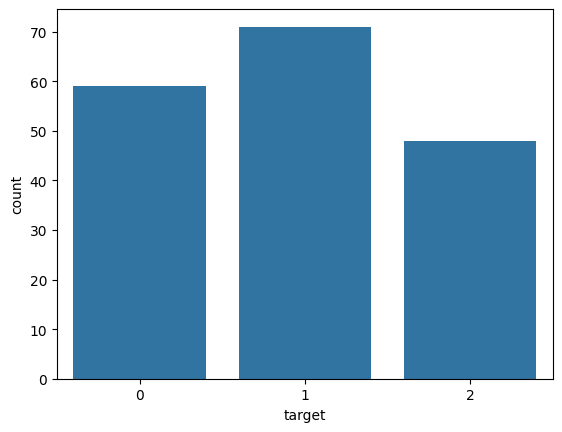

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="target", data=df)
plt.show()

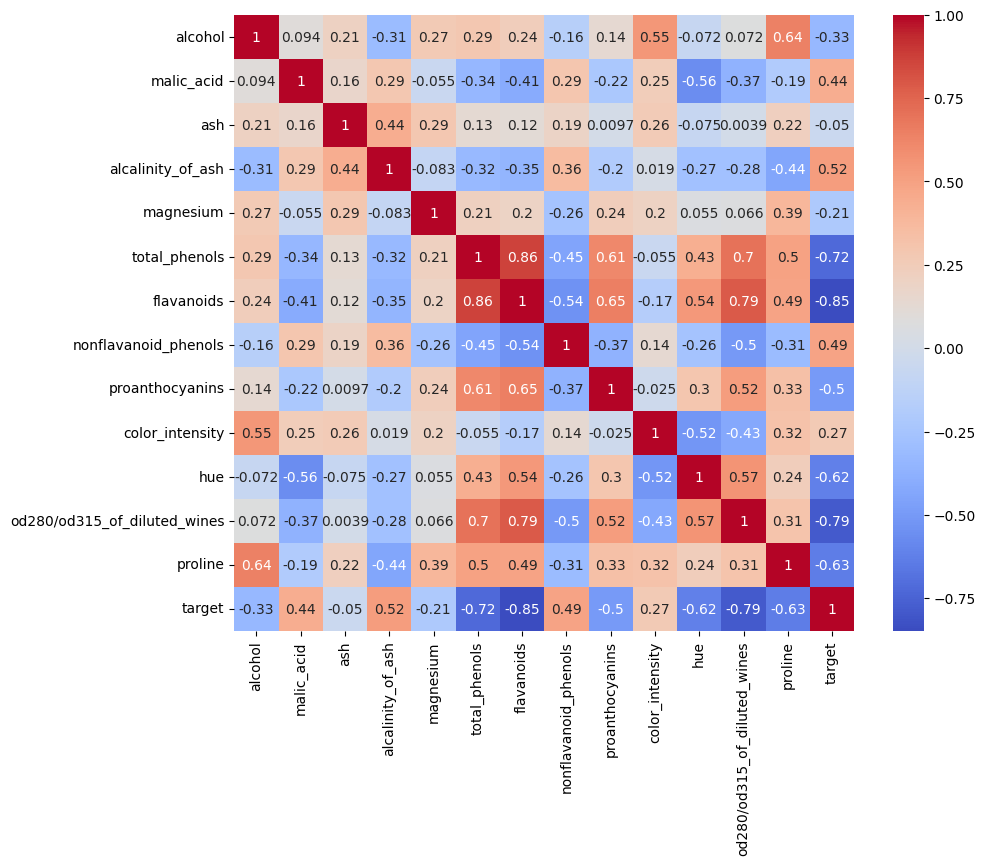

In [98]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm",annot=True)
plt.show()

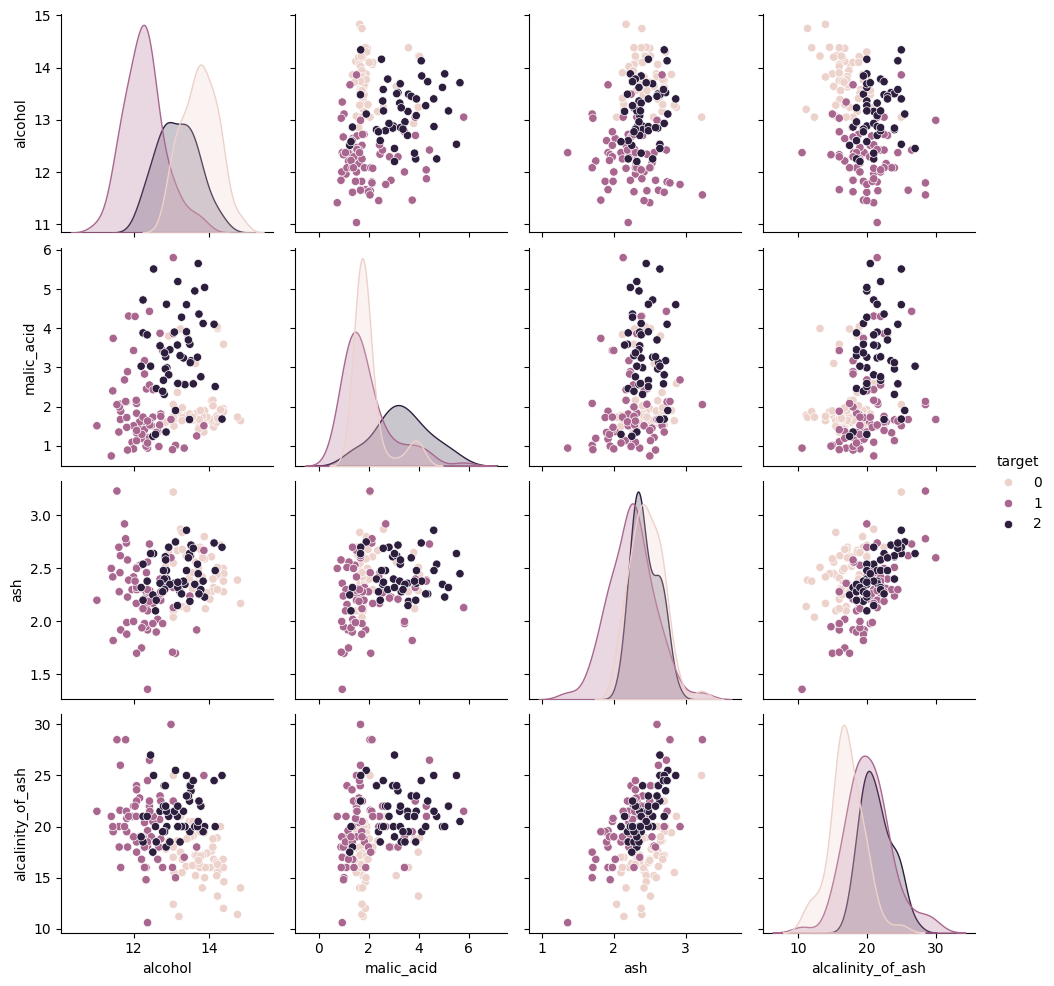

In [99]:
sns.pairplot(df, vars=feature_names[:4], hue="target")
plt.show()

In [100]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [101]:
model_no_svd = LogisticRegression(max_iter=5000)
model_no_svd.fit(X_train, y_train)

y_pred_no_svd = model_no_svd.predict(X_test)
acc_no_svd = accuracy_score(y_test, y_pred_no_svd)

acc_no_svd

0.9814814814814815

In [102]:
svd = TruncatedSVD(n_components=5, random_state=42)

X_train_svd = svd.fit_transform(X_train)
X_test_svd = svd.transform(X_test)

In [103]:
model_svd = LogisticRegression(max_iter=5000)
model_svd.fit(X_train_svd, y_train)

y_pred_svd = model_svd.predict(X_test_svd)
acc_svd = accuracy_score(y_test, y_pred_svd)

acc_svd

0.9629629629629629

In [104]:
print("Explained Variance Ratio:", svd.explained_variance_ratio_)
print("Total Explained Variance:", svd.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.36534764 0.18061236 0.11686396 0.07929204 0.07139212]
Total Explained Variance: 0.8135081129066521


In [105]:
print("Accuracy Without SVD:", acc_no_svd)
print("Accuracy With TruncatedSVD:", acc_svd)

Accuracy Without SVD: 0.9814814814814815
Accuracy With TruncatedSVD: 0.9629629629629629
